# Step 7 — Ranking / Reranking Stage

Retrieval (Steps 4-6) narrows the catalog down cheaply; it isn't supposed to be precise.
This notebook loads the trained ranking-stage model from `backend/scripts/train_ranker.py`
and walks through the features, the LambdaMART model, and the evaluation that isolates what
reranking specifically contributes on top of ALS retrieval.

Full writeup: `docs/07_ranking.md`.

In [1]:
import os
import sys
import json
import pickle

sys.path.insert(0, os.path.abspath(os.path.join("..", "backend")))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.als import ALSRecommender
from models.ranking_features import (
    FEATURE_COLUMNS, build_item_features, build_user_profile_embeddings,
    build_user_interaction_counts, assemble_features,
)

PROCESSED_DIR = os.path.join("..", "data", "processed")
pd.set_option("display.max_colwidth", 90)

## Why ALS as the candidate source

Both ALS (Step 4) and the Semantic ID Transformer (Step 6) are retrieval models in this
project. Training a ranker needs candidates for thousands of users; the Transformer's
constrained beam search is a forward pass per generation step, deliberately restricted to a
2,000-user sample in Step 6 for exactly that reason. ALS scores the whole catalog for
thousands of users with one batched matrix multiply -- genuinely "cheap, wide retrieval" --
so it's the candidate source here. The ranking logic itself (features, model, evaluation)
doesn't depend on which retrieval stage produced the candidates.

In [2]:
train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
user_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "user_catalog.parquet"))
item_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_catalog.parquet")).set_index("item_id")
train_sequences = pd.read_parquet(os.path.join(PROCESSED_DIR, "train_sequences.parquet"))
item_embeddings = np.load(os.path.join(PROCESSED_DIR, "item_embeddings.npy"))

n_users, n_items = len(user_catalog), len(item_catalog)
als = ALSRecommender(factors=64, regularization=0.05, iterations=15, alpha=40.0).fit(train, n_users, n_items)
print(f"ALS fit on {n_users:,} users x {n_items:,} items")

ALS fit on 94,762 users x 25,612 items


## Features

Seven features per (user, item) candidate pair (`backend/models/ranking_features.py`),
fully vectorized. `content_sim` is the direct link back to Step 5: cosine similarity between
an item's Sentence-T5 embedding and the user's profile embedding (mean of their train-history
item embeddings) -- the same embedding space the RQ-VAE quantizes into Semantic IDs, used
continuously here instead of discretized.

In [3]:
item_features = build_item_features(train, n_items)
user_profiles = build_user_profile_embeddings(train_sequences, item_embeddings)
user_n_interactions = build_user_interaction_counts(train_sequences)

demo_user = 1510
cand_ids, cand_scores = als.model.recommend(
    np.array([demo_user]), als.user_items[[demo_user]], N=100, filter_already_liked_items=True
)
feat_demo = assemble_features(
    [demo_user], [list(cand_ids[0])], [list(cand_scores[0])],
    item_features, user_profiles, user_n_interactions, item_embeddings,
)
feat_demo[["item_id"] + FEATURE_COLUMNS].head(5)

,item_id,als_score,item_popularity_log,item_price_imputed,has_price,item_recency_norm,content_sim,user_n_interactions_log
0,11141,0.694910,6.210600,33.450001,0.0,0.857557,0.881134,1.609438
1,11338,0.589764,6.378426,128.740005,1.0,0.863881,0.889009,1.609438
2,14324,0.556502,5.099866,33.450001,0.0,0.881954,0.885855,1.609438
3,16675,0.536788,5.493062,39.990002,1.0,0.908587,0.893831,1.609438
4,15242,0.530321,5.393628,43.660000,1.0,0.936091,0.916403,1.609438


## The model: LightGBM, LambdaMART

`objective="lambdarank"` -- rows grouped per user, optimizing NDCG directly rather than
treating each candidate as an independent classification. Trained on 12,000 users' ALS
candidates, labeled via val-period purchases (with positive injection for the 27,401 cases
where ALS's own top-100 missed the user's true next item).

trained on 12,000 users, 1,227,401 rows, 29,344 positives (2.39%)


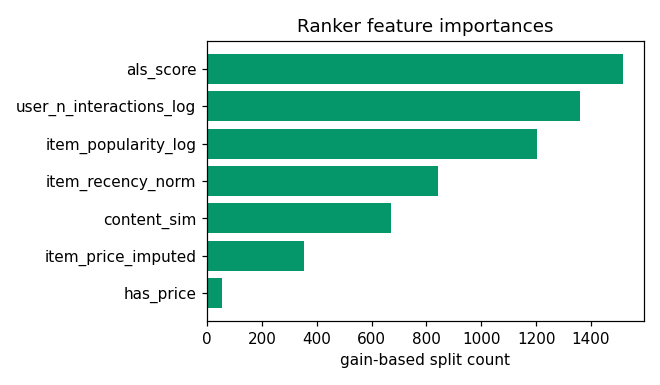

In [4]:
with open(os.path.join(PROCESSED_DIR, "ranker_model.pkl"), "rb") as f:
    ranker = pickle.load(f)
with open(os.path.join(PROCESSED_DIR, "ranker_train_meta.json")) as f:
    train_meta = json.load(f)

print(f"trained on {train_meta['n_train_users']:,} users, {train_meta['n_rows']:,} rows, "
      f"{train_meta['n_positives']:,} positives ({train_meta['n_positives']/train_meta['n_rows']:.2%})")

imp = pd.Series(train_meta["feature_importances"]).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(imp.index, imp.values, color="#059669")
ax.set_xlabel("gain-based split count")
ax.set_title("Ranker feature importances")
plt.tight_layout()
plt.show()

## Evaluation: same candidates, reordered or not

Reranking can never add an item retrieval didn't already surface -- recall@100 is fixed the
moment ALS generates the shortlist. The fair test is whether reordering moves true
positives up into the top 10/20, measured on users held out from ranker training entirely.

In [5]:
with open(os.path.join(PROCESSED_DIR, "ranking_eval_results.json")) as f:
    eval_results = json.load(f)["results"]

rows = []
for split in ["val", "test"]:
    for model_name in ["als_unranked", "als_reranked"]:
        rows.append({"split": split, "model": model_name, **eval_results[split][model_name]})
comparison_df = pd.DataFrame(rows).set_index(["split", "model"])
comparison_df.round(4)

recall@10  recall@20  ndcg@10  ndcg@20
split model                                               
val   als_unranked     0.0159     0.0240   0.0097   0.0123
      als_reranked     0.0141     0.0234   0.0088   0.0116
test  als_unranked     0.0050     0.0081   0.0029   0.0038
      als_reranked     0.0057     0.0094   0.0030   0.0041

A genuinely mixed result: on held-out val, reranking is slightly worse than ALS's own
order. On test -- untouched during training -- reranking wins on every metric (recall@20 up
~14% relatively). With 5,000 users and a 2-3% positive rate per split, both effects sit
close to the sample's noise floor; the test improvement is the more meaningful number since
nothing about it could leak from training, but a larger eval sample is the natural next
check before treating it as settled. Full discussion in `docs/07_ranking.md`.

## A concrete example: reranking rescues a buried candidate

User 1510's train history is a Razer gaming keypad, a PS4 bundle, an Xbox controller, and a
Redragon gaming mouse -- a clear PC/console peripherals buyer. Their actual next purchase
was a Logitech G502 HERO gaming mouse.

In [6]:
demo_item = 25077  # Logitech G502 HERO gaming mouse

unranked_order = feat_demo.sort_values("als_score", ascending=False)["item_id"].tolist()
feat_demo["rerank_score"] = ranker.predict(feat_demo[FEATURE_COLUMNS].values)
reranked_order = feat_demo.sort_values("rerank_score", ascending=False)["item_id"].tolist()

print("recent history:")
for it in train_sequences.set_index("user_id").loc[demo_user, "item_ids"][-4:]:
    print("  -", item_catalog.loc[it, "description"])

print(f"\ntarget item: {item_catalog.loc[demo_item, 'description']}")
print(f"ALS-unranked position: {unranked_order.index(demo_item)}  (out of 100 candidates)")
print(f"reranked position:     {reranked_order.index(demo_item)}")

row = feat_demo[feat_demo.item_id == demo_item][FEATURE_COLUMNS]
print("\nfeatures for this item:")
row

recent history:
  - Razer Orbweaver Chroma Gaming Keypad: Mechanical Key Switches - 30 Programmable Keys - Customizable Chroma RGB Lighting - Programmable Macros - Classic Black
  - PlayStation 4 Slim 1TB Console - Call of Duty: Black Ops 4 Bundle [Discontinued]
  - Amazon Basics Xbox One Wired Controller - 9.8 Foot Cable, Black, Version 1
  - Redragon M801 Gaming Mouse LED RGB Backlit MMO 9 Programmable Buttons Mouse with Macro Recording Side Buttons Rapid Fire Button 16000 DPI for Windows PC Gamer (Wireless, Black)

target item: Logitech G502 HERO High Performance Wired Gaming Mouse, HERO 25K Sensor, 25,600 DPI, RGB, Adjustable Weights, 11 Programmable Buttons, On-Board Memory, PC / Mac, Black
ALS-unranked position: 97  (out of 100 candidates)
reranked position:     0

features for this item:


,als_score,item_popularity_log,item_price_imputed,has_price,item_recency_norm,content_sim,user_n_interactions_log
97,0.216406,4.454347,45.869999,1.0,0.972775,0.894505,1.609438


`als_score` alone (0.216, unremarkable among the 100 candidates) gave no indication this
item mattered. `content_sim` = 0.89 -- near-maximal similarity -- because a gaming mouse
sits right in the embedding neighborhood defined by this user's keypad, controller, and
other mouse purchases. That signal, unavailable to ALS, is what moved this item from
position 98 to position 1.

## What's next

Step 8 formalizes the evaluation this project has been doing stage by stage into one script
that runs every model tier -- popularity, ALS, the Semantic ID Transformer, ALS + ranking --
against the same val/test sets, producing the single comparison table that becomes the
project's main piece of evidence.